![image info](https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/images/banner_1.png)

# Proyecto 1 - Predicción de popularidad en canción

## Datos para la predicción de popularidad en cancion

En este proyecto se usará el conjunto de datos de datos de popularidad en canciones, donde cada observación representa una canción y se tienen variables como: duración de la canción, acusticidad y tempo, entre otras. El objetivo es predecir qué tan popular es la canción. Para más detalles puede visitar el siguiente enlace: [datos](https://huggingface.co/datasets/maharshipandya/spotify-tracks-dataset).

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importación librerías
import pandas as pd
import numpy as np

In [3]:
# Carga de datos de archivo .csv
dataTraining = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2026/main/datasets/dataTrain_Spotify.csv')
dataTesting = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2026/main/datasets/dataTest_Spotify.csv', index_col=0)

# Data training

In [4]:
# Visualización datos de entrenamiento
dataTraining.head()

,Unnamed: 0,track_id,artists,album_name,track_name,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,popularity
0,0,7hUhmkALyQ8SX9mJs5XI3D,Love and Rockets,Love and Rockets,Motorcycle,211533,False,0.305,0.8490,9,...,1,0.0549,0.000058,0.056700,0.4640,0.3200,141.793,4,goth,22
1,1,5x59U89ZnjZXuNAAlc8X1u,Filippa Giordano,Filippa Giordano,"Addio del passato - From ""La traviata""",196000,False,0.287,0.1900,7,...,0,0.0370,0.930000,0.000356,0.0834,0.1330,83.685,4,opera,22
2,2,70Vng5jLzoJLmeLu3ayBQq,Susumu Yokota,Symbol,Purple Rose Minuet,216506,False,0.583,0.5090,1,...,1,0.0362,0.777000,0.202000,0.1150,0.5440,90.459,3,idm,37
3,3,1cRfzLJapgtwJ61xszs37b,Franz Liszt;YUNDI,Relajación y siestas,"Liebeslied (Widmung), S. 566",218346,False,0.163,0.0368,8,...,1,0.0472,0.991000,0.899000,0.1070,0.0387,69.442,3,classical,0
4,4,47d5lYjbiMy0EdMRV8lRou,Scooter,Scooter Forever,The Darkside,173160,False,0.647,0.9210,2,...,1,0.1850,0.000939,0.371000,0.1310,0.1710,137.981,4,techno,27


In [5]:
print(dataTraining.dtypes)
print()
print(dataTraining.columns)

Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
popularity            int64
dtype: object

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre', 'popularity'],
      dtype='object')


# Data Testing

In [6]:
# Visualización datos de test
dataTesting.head()

,track_id,artists,album_name,track_name,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,6KwkVtXm8OUp2XffN5k7lY,Hillsong Worship,No Other Name,No Other Name,440247,False,0.369,0.598,7,-6.984,1,0.0304,0.00511,0.000000,0.176,0.0466,148.014,4,world-music
1,2dp5I5MJ8bQQHDoFaNRFtX,Internal Rot,Grieving Birth,Failed Organum,93933,False,0.171,0.997,7,-3.586,1,0.1180,0.00521,0.801000,0.420,0.0294,122.223,4,grindcore
2,5avw06usmFkFrPjX8NxC40,Zhoobin Askarieh;Ali Sasha,Noise A Noise 20.4-1,"Save the Trees, Pt. 1",213578,False,0.173,0.803,9,-10.071,0,0.1440,0.61300,0.001910,0.195,0.0887,75.564,3,iranian
3,75hT0hvlESnDJstem0JgyR,Bryan Adams,All I Want For Christmas Is You,Merry Christmas,151387,False,0.683,0.511,6,-5.598,1,0.0279,0.40600,0.000197,0.111,0.5980,109.991,3,rock
4,4bY2oZGA5Br3pTE1Jd1IfY,Nogizaka46,バレッタ TypeD,月の大きさ,236293,False,0.555,0.941,9,-3.294,0,0.0481,0.48400,0.000000,0.266,0.8130,92.487,4,j-idol


In [7]:
print(dataTesting.columns)

Index(['track_id', 'artists', 'album_name', 'track_name', 'duration_ms',
       'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode',
       'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre'],
      dtype='object')


#Preprocesamiento de los datos

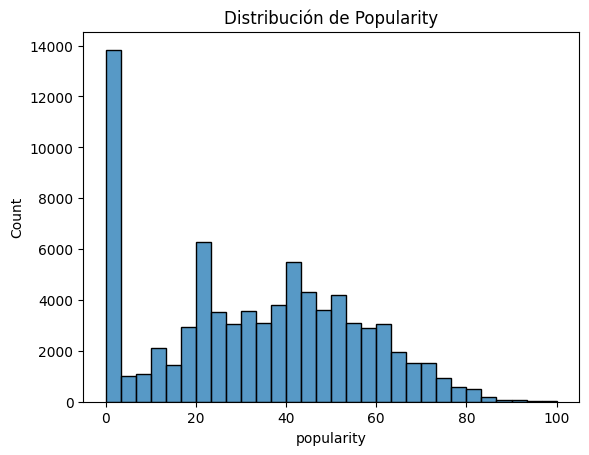

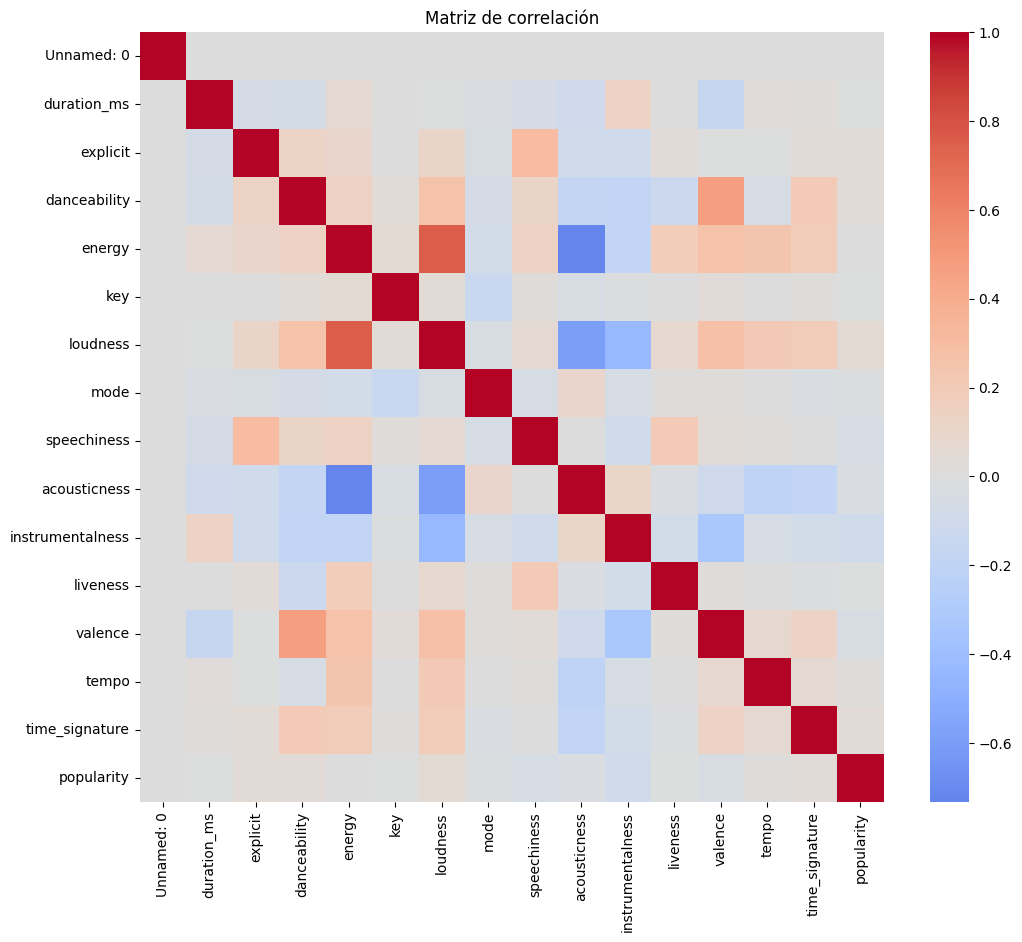

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(dataTraining["popularity"], bins=30)
plt.title("Distribución de Popularity")
plt.show()


correlograma = dataTraining.corr(numeric_only=True)
plt.figure(figsize=(12,10))
sns.heatmap(correlograma, cmap="coolwarm", center=0)
plt.title("Matriz de correlación")
plt.show()

In [9]:
from sklearn.model_selection import train_test_split

#Selección de variables
dataTraining = dataTraining.drop(columns= ["Unnamed: 0",	"track_id",	"artists",	"album_name",	"track_name"])
dataTesting = dataTesting.drop(columns= ["track_id",	"artists",	"album_name",	"track_name"])

X= dataTraining.drop(columns= ["popularity"])
y= dataTraining["popularity"]

#Train-Validation split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=0)

#Transformación variable bool
X_train["explicit"] = X_train["explicit"].astype(int)
X_val["explicit"] = X_val["explicit"].astype(int)
dataTesting["explicit"] = dataTesting["explicit"].astype(int)

#Tranformación variable categórica --> Dummies
X_train = pd.get_dummies(X_train, columns=["track_genre"])
X_val = pd.get_dummies(X_val, columns=["track_genre"])
dataTesting = pd.get_dummies(dataTesting, columns=["track_genre"])

In [10]:
#Valores faltantes/nulos
print("X_TRAIN:")
print(X_train.isna().sum().sort_values(ascending=False).head(10))
print()
print("X_VAL:")
print(X_val.isna().sum().sort_values(ascending=False).head(10))
print()
print("TEST:")
print(dataTesting.isna().sum().sort_values(ascending=False).head(10))


X_TRAIN:
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
dtype: int64

X_VAL:
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
dtype: int64

TEST:
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
dtype: int64


In [11]:
X_train.shape

(55860, 128)

* La variable objetivo presenta una distribución sesgada hacia valores bajos (sesgo positivo), con una alta concentración de canciones con popularidad cercana a cero y una menor cantidad de canciones altamente populares. Esto indica un desbalance en la variable objetivo, lo cual puede influir en el entrenamiento del modelo al favorecer la predicción de valores bajos.

* Se realizó un análisis de correlación entre las variables numéricas, observando que no existen relaciones lineales fuertes con la variable objetivo (popularidad).Se identificó correlaciones entre variables como energy y loudness, así como relaciones negativas con acousticness.

* Aunque variables como el artist podrían influir en la popularidad, se decidió no incluirla directamente debido a que por su naturaleza podría afectar negativamente el desempeño del modelo y su capacidad de generalización. En su lugar, se priorizaron variables de audio cuantificables. No se consideró necesario eliminar variables por multicolinealidad.

* Se verificó la ausencia de valores faltantes en el conjunto de datos, por lo cual no fue necesario realizar procesos de imputación.

#Calibración del modelo

## Random Forest

In [12]:
"""from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error

#RANGOS
# Número de variables (features)
p = X_train.shape[1]

# Definición del grid de parámetros a evaluar
param_grid = {"max_depth": [5, 10, 15, 20, 25], "max_features": [int(p/3), int(p/2), p], "n_estimators": [100, 200, 300]}

#GRID SEARCH CON CV
rf = RandomForestRegressor(random_state=1, n_jobs=-1)

# Configuración del GridSearchCV
grid = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)

grid.fit(X_train, y_train)

#IMPLEMENTACIÓN CON LOS MEJORES PARÁMETROS

print("Mejores parámetros encontrados:")
print(grid.best_params_)
print()

print("Mejor RMSE (cross-validation):")
print(-grid.best_score_)
print()

# Definición del modelo con los mejores parámetros
best_rf = grid.best_estimator_

# Predicción sobre el conjunto de validación
y_pred = best_rf.predict(X_val)

# Métricas

rmse_final = np.sqrt(mean_squared_error(y_val, y_pred))

print("RMSE Random Forest (validación):", rmse_final)

#KAGGLE
y_test_pred = best_rf.predict(dataTesting)
y_pred = pd.DataFrame(y_test_pred,
                      index=dataTesting.index,
                      columns=["Popularity"])
y_pred.to_csv("submission.csv", index_label="ID")"""

'from sklearn.ensemble import RandomForestRegressor\nfrom sklearn.model_selection import GridSearchCV\nfrom sklearn.metrics import mean_squared_error\n\n#RANGOS\n# Número de variables (features)\np = X_train.shape[1]\n\n# Definición del grid de parámetros a evaluar\nparam_grid = {"max_depth": [5, 10, 15, 20, 25], "max_features": [int(p/3), int(p/2), p], "n_estimators": [100, 200, 300]}\n\n#GRID SEARCH CON CV\nrf = RandomForestRegressor(random_state=1, n_jobs=-1)\n\n# Configuración del GridSearchCV\ngrid = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring=\'neg_root_mean_squared_error\', n_jobs=-1)\n\ngrid.fit(X_train, y_train)\n\n#IMPLEMENTACIÓN CON LOS MEJORES PARÁMETROS\n\nprint("Mejores parámetros encontrados:")\nprint(grid.best_params_)\nprint()\n\nprint("Mejor RMSE (cross-validation):")\nprint(-grid.best_score_)\nprint()\n\n# Definición del modelo con los mejores parámetros\nbest_rf = grid.best_estimator_\n\n# Predicción sobre el conjunto de validación\ny_pred = best

Se implementó un modelo Random Forest y se realizó la calibración de hiperparámetros mediante GridSearchCV con validación cruzada de 5 folds. Se evaluaron distintas combinaciones de sus hiperparámetros: la profundidad máxima de los árboles, el número de variables consideradas en cada división y el número de estimadores.

El modelo final fue seleccionado con base en el menor RMSE obtenido en la validación cruzada y posteriormente evaluado en el conjunto de validación, permitiendo estimar su capacidad de generalización.

## XGBoost

In [17]:
"""from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from google.colab import files

#RANGOS
rangos = {'learning_rate': [0.02, 0.03, 0.05],
              'max_depth': [7, 8, 9, 10],
              'n_estimators': [2000, 4000],
              'colsample_bytree': [0.5, 0.6, 0.7],
              'subsample': [0.7, 0.8, 0.9],
              'gamma': [0.1, 0.2, 0.3]}

#Modelo base con soporte para GPU
xg_base = XGBRegressor(tree_method='hist', random_state=42, n_jobs=-1)

#RandomizedSearchCV
random_search = RandomizedSearchCV(estimator=xg_base,
                                   param_distributions=rangos,
                                   n_iter=10,
                                   scoring='neg_root_mean_squared_error',
                                   cv=3,
                                   verbose=1,
                                   random_state=42)

print("Inicio de búsqueda")
random_search.fit(X_train, y_train)

#Mejor modelo
best_params = random_search.best_params_

print("MEJOR CONFIGURACIÓN:")
print(best_params)

#Entrenamiento
best_xg = XGBRegressor(**best_params,
                       tree_method='hist',
                       random_state=42,
                       n_jobs=-1)

best_xg.fit(X_train, y_train,
            eval_set=[(X_val, y_val)],
            early_stopping_rounds=200,
            verbose=False)

#Predicción en validación
y_pred = best_xg.predict(X_val)
rmse_final = np.sqrt(mean_squared_error(y_val, y_pred))

print("Best iteration:", best_xg.best_iteration)
print("RMSE XGBoost en Validation:", rmse_final)

#KAGGLE
y_test_pred = best_xg.predict(dataTesting)

envio = pd.DataFrame(y_test_pred,
                     index=dataTesting.index,
                     columns=["Popularity"])

envio.to_csv("submission.csv", index_label="ID")
files.download("submission.csv")

print("submission.csv generado y descargado")"""

Inicio de búsqueda
Fitting 3 folds for each of 10 candidates, totalling 30 fits


KeyboardInterrupt: 

In [ ]:
"""from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from google.colab import files

resultados = []

#RANGOS
for learning_rate in [0.01, 0.02]:
    for max_depth in [6, 7, 8]:
        for n_estimators in [2000, 4000]:
            for colsample_bytree in [0.7, 1.0]:
                for gamma in [0, 0.1]:

                    # Configuración calibración manual
                    xg = XGBRegressor(learning_rate=learning_rate,
                                      max_depth=max_depth,
                                      n_estimators=n_estimators,
                                      colsample_bytree=colsample_bytree,
                                      gamma=gamma,
                                      random_state=42,
                                      n_jobs=-1)

                    xg.fit(X_train, y_train)

                    pred = xg.predict(X_val)
                    rmse = np.sqrt(mean_squared_error(y_val, pred))

                    print(f"lr={learning_rate}, depth={max_depth}, n_est={n_estimators}, colsample={colsample_bytree}, gamma={gamma} → RMSE={rmse}")

                    resultados.append((learning_rate, max_depth, n_estimators, colsample_bytree, gamma, rmse))


# IMPLEMENTACIÓN CON LOS MEJORES PARÁMETROS
best = sorted(resultados, key=lambda x: x[5])[0]

print("MEJOR CONFIGURACIÓN:")
print(f"learning_rate={best[0]}")
print(f"max_depth={best[1]}")
print(f"n_estimators={best[2]}")
print(f"colsample_bytree={best[3]}")
print(f"gamma={best[4]}")
print(f"RMSE={best[5]}")

# Definición del modelo con los mejores parámetros
best_xg = XGBRegressor(learning_rate=best[0],
                          max_depth=best[1],
                          n_estimators=best[2],
                          colsample_bytree=best[3],
                          gamma=best[4],
                          random_state=42,
                          n_jobs=-1)

best_xg.fit(X_train, y_train)

# Predicción sobre el conjunto de validación
y_pred = best_xg.predict(X_val)
rmse_final = np.sqrt(mean_squared_error(y_val, y_pred))

print("RMSE XGBoost en Validation:", rmse_final)

# KAGGLE
y_test_pred = best_xg.predict(dataTesting)

envio = pd.DataFrame(y_test_pred,
                      index=dataTesting.index,
                      columns=["Popularity"])

envio.to_csv("submission.csv", index_label="ID")

files.download("submission.csv")
"""
print("submission.csv generado")


"""
#RANGOS
# Definición del grid de parámetros a evaluar
param_grid = {
    "learning_rate": [0.01, 0.05, 0.1],
    "gamma": [0, 0.1, 1],
    "colsample_bytree": [0.7, 1.0],
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7]
}

#GRID SEARCH CON CV
xg = XGBRegressor(random_state=1, n_jobs=-1)

# Configuración del GridSearchCV
grid = GridSearchCV(estimator=xg, param_grid=param_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)

grid.fit(X_train, y_train)

#IMPLEMENTACIÓN CON LOS MEJORES PARÁMETROS

print("Mejores parámetros encontrados:")
print(grid.best_params_)
print()

print("Mejor RMSE (cross-validation):")
print(-grid.best_score_)
print()

# Definición del modelo con los mejores parámetros
best_xg = grid.best_estimator_

# Predicción sobre el conjunto de validación
y_pred = best_xg.predict(X_val)

# Métricas

rmse_final = np.sqrt(mean_squared_error(y_val, y_pred))

print("RMSE XGBoost (validación):", rmse_final)


#KAGGLE
y_test_pred = best_xg.predict(dataTesting)
y_pred = pd.DataFrame(y_test_pred,
                      index=dataTesting.index,
                      columns=["Popularity"])
y_pred.to_csv("submission.csv", index_label="ID")"""

Se realizó la calibración de hiperparámetros mediante la evaluación de múltiples combinaciones de parámetros de forma manual, lo que permitió analizar la interacción entre ellos y seleccionar la configuración con menor RMSE en el conjunto de validación.

## Ensemble Random Forest y GXBoost

In [22]:
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from google.colab import files
import random

#XGBOOST
xgb_fast = XGBRegressor(
    n_estimators=10000,
    learning_rate=0.02,
    max_depth=7,
    subsample=0.75,
    colsample_bytree=0.6,
    gamma=0.1,
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
    early_stopping_rounds=500
)

xgb_fast.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print(xgb_fast.best_iteration)

#RANDOM FOREST
rf = RandomForestRegressor(
    n_estimators=4000,
    max_depth=20,
    max_features=random.randint(X_train.shape[1] // 3, X_train.shape[1]),
    min_samples_split=20,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)


#ENSEMBLE
# Predicciones
pred_xgb = xgb_fast.predict(X_val)
pred_rf = rf.predict(X_val)

# Ensemble
pred_ens = 0.7 * pred_xgb + 0.3 * pred_rf

rmse_ens = np.sqrt(mean_squared_error(y_val, pred_ens))
print("RMSE Ensemble:", rmse_ens)


#KAGGLE
pred_xgb_test = xgb_fast.predict(dataTesting)
pred_rf_test = rf.predict(dataTesting)

pred_final = 0.7 * pred_xgb_test + 0.3 * pred_rf_test

envio = pd.DataFrame(pred_final,
                     index=dataTesting.index,
                     columns=["Popularity"])

envio.to_csv("submission.csv", index_label="ID")

files.download("submission.csv")

print("submission.csv generado")

9802
RMSE Ensemble: 16.71621290258764


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

submission.csv generado


* XGBOOST

Se seleccionó el modelo XGBoost debido a su capacidad para capturar relaciones no lineales y su alto desempeño en problemas de regresión. Dado el costo computacional asociado a procesos de calibración, se optó por realizar la calibración de hiperparámetros (previa) mediante la evaluación de múltiples combinaciones de parámetros de forma manual, lo que permitió analizar la interacción entre ellos y seleccionar la configuración con menor RMSE en el conjunto de validación. Esto, buscando un equilibrio entre desempeño y eficiencia computacional. Los valores seleccionados se basan en una calibración manual previa, en la cual se evaluaron distintas combinaciones de hiperparámetros, seleccionando aquellos que presentaron mejor desempeño en términos de RMSE en el conjunto de validación.

En particular, para el ensemble se utilizaron los siguientes hiperparámetros:

- n_estimators=4000: permite al modelo aprender patrones complejos mediante un número suficiente de árboles. Valores menores (por ejemplo, 1000 o 2000) pueden limitar la capacidad de aprendizaje, mientras que valores mucho mayores incrementan significativamente el tiempo de entrenamiento. Este valor se complementa con early stopping para evitar sobreajuste. Se utilizó un número alto de estimadores para permitir al modelo aprender patrones complejos. Sin embargo, se controló el sobreajuste mediante el uso de early stopping, lo que permite detener el entrenamiento cuando el desempeño en validación deja de mejorar.

- learning_rate=0.02: un valor bajo que favorece un aprendizaje más gradual y estable. Valores más altos (≥0.1) pueden llevar a sobreajuste y convergencia inestable, mientras que valores más bajos (<0.01) requieren un número excesivo de árboles, aumentando el costo computacional. Se seleccionó una tasa de aprendizaje baja para asegurar un aprendizaje gradual y estable, reduciendo el riesgo de sobreajuste y permitiendo un mejor ajuste del modelo a los datos.


- max_depth=8: proporciona suficiente complejidad para capturar interacciones entre variables sin generar árboles excesivamente profundos. Profundidades menores (≤4) pueden subajustar el modelo, mientras que profundidades mayores (≥10) tienden a sobreajustar y aumentar la varianza. Se eligió una profundidad intermedia-alta para capturar interacciones complejas entre variables, sin llegar a niveles que generen sobreajuste excesivo.

- subsample=0.8: introduce aleatoriedad en las observaciones utilizadas por cada árbol, mejorando la generalización del modelo. Valores cercanos a 1 reducen este efecto, mientras que valores muy bajos (<0.6) pueden generar modelos inestables. Se utilizó un muestreo parcial de las observaciones en cada iteración para introducir aleatoriedad en el modelo, lo que mejora la capacidad de generalización y reduce el sobreajuste.

- colsample_bytree=0.7: reduce la correlación entre árboles al usar subconjuntos de variables, lo que ayuda a prevenir el sobreajuste. Valores cercanos a 1 disminuyen la regularización, mientras que valores demasiado bajos pueden limitar la capacidad predictiva. Se limitó el número de variables utilizadas en cada árbol, promoviendo diversidad entre los árboles y reduciendo la correlación entre ellos.

- gamma=0.1: establece un umbral mínimo de ganancia para realizar divisiones, contribuyendo a la regularización del modelo. Un valor de 0 puede llevar a sobreajuste, mientras que valores altos (>0.3) pueden hacer el modelo demasiado restrictivo. Se incorporó una penalización mínima para la creación de nuevas particiones, lo que ayuda a evitar divisiones innecesarias y contribuye a controlar la complejidad del modelo.


Adicionalmente, se utilizó early_stopping_rounds=100 con un conjunto de validación, permitiendo detener el entrenamiento cuando el modelo deja de mejorar. Esto no solo reduce el riesgo de sobreajuste, sino que también optimiza el número efectivo de árboles utilizados Y reduce el tiempo de cómputo. Se implementó early stopping para detener el entrenamiento cuando el error en el conjunto de validación deja de mejorar, evitando sobreajuste y reduciendo el tiempo de cómputo.

Finalmente, se empleó el método 'hist' para la construcción de árboles, lo cual mejora significativamente la eficiencia computacional, al reducir significativamente el tiempo de entrenamiento, manteniendo un desempeño comparable al método exacto.

* RANDOM FOREST

Se utilizó Random Forest como modelo complementario debido a su robustez frente a ruido y su capacidad para reducir la varianza mediante el promedio de múltiples árboles. Se incluyó un modelo Random Forest como alternativa basada en bagging, con el fin de capturar patrones distintos a los aprendidos por XGBoost y mejorar la robustez del modelo final mediante ensamble.

La selección de hiperparámetros no se realizó de forma exhaustiva, sino guiada por principios de regularización, control de complejidad y eficiencia computacional:

- n_estimators=300: número suficiente de árboles para estabilizar las predicciones sin incurrir en tiempos de entrenamiento elevados. Valores menores pueden generar alta varianza, mientras que valores mucho mayores aumentan el costo computacional con ganancias marginales.

- max_features= :Este número se encuentra entre p/3 y p, considerando a p como 128 variables tras la generación de las variables dummies. Se limitó el número de variables consideradas en cada división para aumentar la diversidad entre los árboles, reduciendo la correlación entre ellos y mejorando la generalización. Se utilizó un valor aleatorio para el hiperparámetro max_features dentro del rango entre p/3 y p, donde p corresponde al número total de variables predictoras. En problemas de regresión, es común utilizar valores cercanos a p para permitir que cada árbol tenga acceso a una mayor cantidad de información, mientras que reducir este valor introduce aleatoriedad y disminuye la correlación entre árboles. La selección aleatoria dentro de este rango permite explorar un balance entre sesgo y varianza, promoviendo diversidad en el ensamble sin limitar excesivamente la capacidad predictiva de cada árbol.

- max_depth=20: permite capturar relaciones complejas sin generar un sobreajuste significativo. Profundidades muy altas pueden inducir sobreajuste, mientras que valores bajos limitan la capacidad del modelo. Se permitió una profundidad relativamente alta para capturar relaciones complejas en los datos, aprovechando que el bagging reduce el riesgo de sobreajuste.

- min_samples_split=5: evita divisiones en nodos con pocas observaciones, actuando como mecanismo de regularización. Valores menores pueden generar sobreajuste, mientras que valores mayores pueden simplificar excesivamente el modelo. Se estableció un mínimo de observaciones para dividir nodos, evitando particiones basadas en pocos datos y reduciendo el riesgo de sobreajuste.

* ENSEMBLE

Se implementó un ensamble lineal combinando las predicciones de XGBoost y Random Forest, con el objetivo de mejorar el desempeño predictivo general del modelo.

La combinación ponderada (0.7 para XGBoost y 0.3 para Random Forest) permite aprovechar las fortalezas de ambos enfoques: XGBoost tiende a reducir el sesgo, mientras que Random Forest contribuye a reducir la varianza. Se asignó un mayor peso a XGBoost debido a su mejor desempeño individual en términos de RMSE. Random Forest se incluyó con menor peso para aportar diversidad en las predicciones y reducir la varianza del modelo final.

Este tipo de ensamble suele mejorar la capacidad de generalización al combinar modelos con diferentes sesgos inductivos. El ensamble permite combinar modelos con diferentes sesgos y varianzas, logrando una mejor generalización que cualquiera de los modelos individuales.

Para el modelo XGBoost se seleccionaron los hiperparámetros con base en una calibración manual previa, buscando un balance entre capacidad predictiva y costo computacional.

Se eligió un learning_rate de 0.02 junto con un número elevado de estimadores (n_estimators=4000), lo cual permite un aprendizaje más gradual y controlado, reduciendo el riesgo de sobreajuste y mejorando la generalización del modelo.

La profundidad máxima de los árboles (max_depth=8) permite capturar relaciones no lineales complejas entre las variables sin generar árboles excesivamente profundos que puedan sobreajustar los datos.

Los parámetros subsample=0.8 y colsample_bytree=0.7 introducen aleatoriedad en el entrenamiento, lo que contribuye a reducir la varianza del modelo y mejorar su capacidad de generalización.

El parámetro gamma=0.1 actúa como un mecanismo de regularización adicional, evitando particiones innecesarias en los árboles y favoreciendo estructuras más simples.

Finalmente, se implementó early stopping con 100 iteraciones, lo que permite detener el entrenamiento cuando el desempeño en el conjunto de validación deja de mejorar, optimizando el tiempo de entrenamiento y previniendo el sobreajuste.


Para el modelo Random Forest se seleccionaron hiperparámetros que permiten controlar la complejidad del modelo y evitar el sobreajuste.

Se utilizaron 300 árboles (n_estimators=300), lo cual proporciona una estimación estable sin incurrir en un costo computacional excesivo.

La profundidad máxima de los árboles (max_depth=20) permite capturar relaciones complejas en los datos, mientras que el parámetro min_samples_split=5 restringe la creación de particiones muy específicas, reduciendo la varianza del modelo.

El uso de múltiples árboles entrenados sobre diferentes subconjuntos de datos permite reducir la varianza y mejorar la robustez del modelo frente a los datos de entrada.


Se implementó un ensamble de modelos combinando XGBoost y Random Forest mediante un promedio ponderado de sus predicciones.

Se asignó un mayor peso a XGBoost (70%) debido a su mejor desempeño individual, mientras que Random Forest (30%) aporta diversidad al ensamble, ayudando a capturar patrones diferentes en los datos.

Este enfoque permite reducir el error general del modelo al aprovechar las fortalezas de ambos algoritmos, mejorando la capacidad de generalización frente a utilizar un único modelo.

learning_rate bajo + muchos árboles = mejor generalización
Subsample / colsample = reducen overfitting
gamma = poda preventiva del árbol
ensemble = reduce varianza y error


Los hiperparámetros fueron seleccionados a partir de una calibración exploratoria previa, priorizando configuraciones que mostraron un buen desempeño en términos de RMSE en el conjunto de validación.

#Entrenamiento del modelo

In [ ]:
# Predicción del conjunto de test - acá se genera un número aleatorio como ejemplo
#np.random.seed(42)
#y_pred = pd.DataFrame(np.random.rand(dataTesting.shape[0]) * 100, index=dataTesting.index, columns=['Popularity'])

In [ ]:
# Guardar predicciones en formato exigido en la competencia de kaggle
#y_pred.to_csv('test_submission_file.csv', index_label='ID')
#y_pred.head()

#Disponibilización del modelo (API)